# Siamese DNN — raw embeddings, end-to-end

Predicts pairwise item correlations from raw item embeddings plus a single
cosine-similarity aux feature (`global_sim`). Replaces an earlier autoencoder +
MLP pipeline with a single end-to-end network so the compression step can learn
task-relevant structure instead of being constrained by reconstruction loss.

Architecture:
- A shared MLP encodes each item's raw embedding (dimensionality is read from
  the embedding file at load time, `EMB_DIM`) down to a smaller task-specific
  representation (`ENCODER_DIMS`, 384 here).
- The two encoded vectors are combined via `concat[h1, h2, h1*h2, |h1-h2|]`,
  giving the head both raw and interaction features without prescribing a
  fixed similarity metric.
- A single aux feature - `global_sim`, the cosine similarity between the two
  items' raw embeddings - is concatenated into the head MLP.
- Target is in Fisher-z space; loss is Huber; final `tanh` is applied at inference
  to map back to `r`.
- Split is `item_disjoint`: items in the validation fold never appear in any
  training pair.

Memory note: item embeddings are stored once as a frozen lookup table on the
GPU (`ITEM_EMB`, shape n_items x `EMB_DIM`); the item count and embedding
dimension are printed when the file loads. The pair table only carries
`(idx1, idx2, r, aux)` per row.


In [ ]:
# --- 1. Imports & config ---
import os
import gc
import numpy as np
import polars as pl
import polars.selectors as cs
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import QuantileTransformer
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import seaborn as sns

# ---- Paths ----
emb_model       = "Qwen-Qwen3-Embedding-8B" # Qwen-Qwen3-Embedding-8B performs best


train_pair_path = f"../../data/raw/item_correlations.parquet"
train_emb_path  = f"../../data/raw/{emb_model}/embeddings_raw.parquet"
# Holdout pair file: full set (item-disjoint + cross-scale combined)
hold_pair_path  = "../../data/raw/holdout_item_correlations.parquet"
hold_emb_path   = f"../../data/raw/{emb_model}/holdout_embeddings_raw.parquet"
CKPT_PATH       = f"../../models/{emb_model}/dnn_siamese_cor.pt"

# ---- Split ----
OUTER_VAL_FRAC = 0.1
R_CLIP         = 0.999   # clip r before atanh to keep z finite

# ---- Hyperparams (tuned in ./optuna_hpt/dnn_siamese_holdout_tuning) ----
# Note that the hyperparams are being picked because they performed well on the holdout data, 
# so for true generalization metrics look at the model-eval on validation data from Hommel and Arslan (2023)
# in model_validation.ipynb
ENCODER_DIMS = (384,)
HEAD_DIMS    = (256, 130)
DROPOUT      = 0.226
USE_SKIP     = False
BATCH_SIZE   = 512
LR           = 0.0002
WEIGHT_DECAY = 0.0023
HUBER_BETA   = 0.127
GRAD_CLIP    = 1.863
SCHED_PATIENCE = 4    # ReduceLROnPlateau patience (HPT v3)
SEED = 42
MAX_EPOCHS = 100
PATIENCE = 15


device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
torch.manual_seed(SEED); np.random.seed(SEED)
os.makedirs(f"../../models/{emb_model}", exist_ok=True)

Device: cuda:0


In [2]:
# --- 2. Load item embeddings + pair table; build index ---

emb_df   = pl.read_parquet(train_emb_path)
emb_cols = [c for c in emb_df.columns if c.startswith("emb")]
EMB_DIM  = len(emb_cols)
print(f"Item embeddings: {emb_df.shape}  emb_dim={EMB_DIM}")

# Item-text -> integer index; embeddings live on the GPU as a frozen lookup
item_to_idx = {name: i for i, name in enumerate(emb_df["item"].to_list())}
ITEM_EMB = torch.tensor(
    emb_df.select(emb_cols).to_numpy(), dtype=torch.float32
).to(device)
print(f"ITEM_EMB on device: {tuple(ITEM_EMB.shape)}  ({ITEM_EMB.element_size() * ITEM_EMB.nelement() / 1e6:.1f} MB)")

# Pair table (drop self-correlations + nulls)
dat = pl.read_parquet(train_pair_path).filter(
    (pl.col("r").is_not_null()) & (pl.col("r") != 1)
)

def add_global_sim(df, emb, name_to_idx, chunk=50_000):
    known = pl.Series("item", list(name_to_idx.keys())).implode()
    df = df.filter(pl.col("Parameter1").is_in(known) & pl.col("Parameter2").is_in(known))
    i1 = np.fromiter((name_to_idx[p] for p in df["Parameter1"].to_list()), np.int64)
    i2 = np.fromiter((name_to_idx[p] for p in df["Parameter2"].to_list()), np.int64)

    En  = torch.nn.functional.normalize(emb, dim=1)        # unit rows, computed once
    out = np.empty(len(i1), dtype=np.float32)
    with torch.no_grad():
        for s in range(0, len(i1), chunk):
            sl = slice(s, s + chunk)
            a = En[torch.as_tensor(i1[sl], device=En.device)]
            b = En[torch.as_tensor(i2[sl], device=En.device)]
            out[sl] = (a * b).sum(dim=1).cpu().numpy()      # cosine = dot of unit vecs
    return df.with_columns(pl.Series("global_sim", out))

dat = add_global_sim(dat, ITEM_EMB, item_to_idx)   # before the item-disjoint split

print(f"Pair rows (raw): {dat.height:,}")

# Drop pairs referencing items missing from the embedding table (~5 currently)
known = pl.Series("item", list(item_to_idx.keys())).implode()
dat = dat.filter(pl.col("Parameter1").is_in(known) & pl.col("Parameter2").is_in(known)).select(
    cs.contains('Para') | cs.contains('prod'), pl.col(['global_sim', 'r'])
)
print(f"Pair rows (with embeddings): {dat.height:,}")


Item embeddings: (3127, 4097)  emb_dim=4096
ITEM_EMB on device: (3127, 4096)  (51.2 MB)
Pair rows (raw): 452,026
Pair rows (with embeddings): 452,026


In [3]:
# --- 3. Aux feature column ---
# The head takes a single auxiliary feature: global_sim (cosine similarity
# between the two items' raw embeddings).

aux_numeric = ["global_sim"]
print(f"Aux numeric: {len(aux_numeric)}")

Aux numeric: 1


In [4]:
# --- 4. item_disjoint split ---
# Split the unique items that actually appear in the pair table by OUTER_VAL_FRAC.
# Mixed pairs (one train item + one val item) get dropped so val stays strictly
# item-disjoint from train - the realistic "new items" setting.

items_all = (
    pl.concat([
        dat.select(pl.col("Parameter1").alias("item")),
        dat.select(pl.col("Parameter2").alias("item")),
    ]).unique().to_series().sample(fraction=1.0, seed=SEED)
)
split_idx   = int(len(items_all) * (1 - OUTER_VAL_FRAC))
train_items = items_all.slice(0, split_idx).implode()
outer_items = items_all.slice(split_idx, None).implode()

train_df = dat.filter(pl.col("Parameter1").is_in(train_items) & pl.col("Parameter2").is_in(train_items))
outer_df = dat.filter(pl.col("Parameter1").is_in(outer_items) & pl.col("Parameter2").is_in(outer_items))
dropped  = dat.height - train_df.height - outer_df.height
print(
    f"Split: item-disjoint | train pairs {train_df.height:,} | outer val pairs {outer_df.height:,} | "
    f"dropped mixed pairs: {dropped:,}"
)


Split: item-disjoint | train pairs 362,865 | outer val pairs 4,839 | dropped mixed pairs: 84,322


In [5]:
# --- 5. Fit aux feature preprocessor on the training pool only ---
# QuantileTransformer to a normal target so the heavy-tailed global_sim feature
# doesn't dominate the head.

scaler  = QuantileTransformer(
    output_distribution="normal", n_quantiles=1000,
    subsample=200_000, random_state=SEED,
).fit(train_df.select(pl.col('global_sim')).to_numpy())

AUX_DIM = scaler.transform(train_df.select(pl.col('global_sim')).head(1).to_numpy()).shape[1]
print(f"AUX_DIM (numeric) = {AUX_DIM}")


def featurize_pairs(df):
    """Return (idx1, idx2, aux, y) numpy arrays. Row order matches df."""
    idx1 = np.fromiter((item_to_idx[p] for p in df["Parameter1"].to_list()), dtype=np.int64)
    idx2 = np.fromiter((item_to_idx[p] for p in df["Parameter2"].to_list()), dtype=np.int64)
    aux = scaler.transform(df.select(pl.col('global_sim')).to_numpy())
    y = df.select("r").to_numpy().flatten().astype(np.float32)
    return idx1, idx2, aux, y


train_idx1, train_idx2, train_aux, train_y = featurize_pairs(train_df)
outer_idx1, outer_idx2, outer_aux, outer_y = featurize_pairs(outer_df)
print(f"train tensors: idx1 {train_idx1.shape} aux {train_aux.shape} y {train_y.shape}")
print(f"outer tensors: idx1 {outer_idx1.shape} aux {outer_aux.shape} y {outer_y.shape}")

AUX_DIM (numeric) = 1


train tensors: idx1 (362865,) aux (362865, 1) y (362865,)
outer tensors: idx1 (4839,) aux (4839, 1) y (4839,)


In [6]:
# --- 6. Move pair tensors to device ---
# Pair table footprint stays tiny because the raw embeddings stay in ITEM_EMB
# - we only carry (int idx, aux, target) per row.

train_idx1_t = torch.tensor(train_idx1, dtype=torch.long,    device=device)
train_idx2_t = torch.tensor(train_idx2, dtype=torch.long,    device=device)
train_aux_t  = torch.tensor(train_aux,  dtype=torch.float32, device=device)
train_y_z    = torch.tensor(
    np.arctanh(np.clip(train_y, -R_CLIP, R_CLIP)), dtype=torch.float32, device=device
)

outer_idx1_t = torch.tensor(outer_idx1, dtype=torch.long,    device=device)
outer_idx2_t = torch.tensor(outer_idx2, dtype=torch.long,    device=device)
outer_aux_t  = torch.tensor(outer_aux,  dtype=torch.float32, device=device)
outer_y_r    = outer_y.astype(np.float32)   # r-space numpy, for reporting


In [7]:
# --- 7. Model ---
# Architecture lives in siamese_model.py (shared with model_validation.ipynb).

from siamese_model import SiameseEncoder, SiameseDNN

model = SiameseDNN(
    emb_dim=EMB_DIM, aux_dim=AUX_DIM,
    encoder_dims=ENCODER_DIMS, head_dims=HEAD_DIMS,
    dropout=DROPOUT, use_skip=USE_SKIP,
).to(device)
print(model)
print(f"\nTrainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")


SiameseDNN(
  (encoder): SiameseEncoder(
    (net): Sequential(
      (0): Linear(in_features=4096, out_features=384, bias=True)
      (1): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
      (2): GELU(approximate='none')
      (3): Dropout(p=0.226, inplace=False)
    )
  )
  (head): Sequential(
    (0): Linear(in_features=1537, out_features=256, bias=True)
    (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.226, inplace=False)
    (4): Linear(in_features=256, out_features=130, bias=True)
    (5): LayerNorm((130,), eps=1e-05, elementwise_affine=True)
    (6): GELU(approximate='none')
    (7): Dropout(p=0.226, inplace=False)
  )
  (out): Linear(in_features=130, out_features=1, bias=True)
)

Trainable params: 2,002,057


In [8]:
# --- 8. Training loop ---
# AdamW + Huber on Fisher-z, ReduceLROnPlateau on outer-val r-space RMSE,
# early-stop after PATIENCE epochs without improvement. Best checkpoint
# (by outer-val RMSE) is the one we load for the final eval.

optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=SCHED_PATIENCE
)
criterion = nn.SmoothL1Loss(beta=HUBER_BETA)

history    = {"train_loss": [], "outer_val_rmse": []}
best_rmse  = float("inf")
since_best = 0
rng        = np.random.default_rng(SEED)
n_train    = train_idx1_t.shape[0]

for epoch in range(MAX_EPOCHS):
    # ---- Train pass ----
    model.train()
    perm = rng.permutation(n_train)
    running = 0.0
    for start in range(0, n_train, BATCH_SIZE):
        idx_t = torch.from_numpy(perm[start:start + BATCH_SIZE]).to(device)
        e1 = ITEM_EMB[train_idx1_t[idx_t]]
        e2 = ITEM_EMB[train_idx2_t[idx_t]]
        aux = train_aux_t[idx_t]
        yb  = train_y_z[idx_t]

        optimizer.zero_grad()
        loss = criterion(model(e1, e2, aux), yb)
        loss.backward()
        if GRAD_CLIP > 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP)
        optimizer.step()
        running += loss.item() * idx_t.size(0)
    train_loss = running / n_train

    # ---- Outer val (RMSE in r-space after tanh inverse) ----
    model.eval()
    with torch.no_grad():
        chunks = []
        for s in range(0, outer_idx1_t.shape[0], 8192):
            i1c = outer_idx1_t[s:s+8192]; i2c = outer_idx2_t[s:s+8192]
            ac  = outer_aux_t[s:s+8192]
            chunks.append(torch.tanh(model(ITEM_EMB[i1c], ITEM_EMB[i2c], ac)).cpu().numpy())
        outer_preds_r = np.concatenate(chunks)
    outer_rmse = float(np.sqrt(np.mean((outer_preds_r - outer_y_r) ** 2)))

    scheduler.step(outer_rmse)
    history["train_loss"].append(train_loss)
    history["outer_val_rmse"].append(outer_rmse)

    # Track best by outer-val RMSE; checkpoint when we improve
    if outer_rmse < best_rmse - 1e-5:
        best_rmse  = outer_rmse
        since_best = 0
        torch.save(model.state_dict(), CKPT_PATH)
    else:
        since_best += 1

    if epoch % 5 == 0 or since_best >= PATIENCE:
        lr_now = optimizer.param_groups[0]["lr"]
        print(
            f"Epoch {epoch+1:3d} | train Huber(z) {train_loss:.5f} | "
            f"outer RMSE {outer_rmse:.5f} | best {best_rmse:.5f} | lr {lr_now:.2e}"
        )
    if since_best >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch+1}.")
        break

model.load_state_dict(torch.load(CKPT_PATH, map_location=device))
model.eval()
print(f"\nLoaded best checkpoint (outer val RMSE = {best_rmse:.5f}) from {CKPT_PATH}")


Epoch   1 | train Huber(z) 0.04902 | outer RMSE 0.09698 | best 0.09698 | lr 2.00e-04
Epoch   6 | train Huber(z) 0.01615 | outer RMSE 0.09083 | best 0.08954 | lr 2.00e-04
Epoch  11 | train Huber(z) 0.01348 | outer RMSE 0.08916 | best 0.08709 | lr 2.00e-04
Epoch  16 | train Huber(z) 0.01140 | outer RMSE 0.08982 | best 0.08709 | lr 1.00e-04
Epoch  21 | train Huber(z) 0.01073 | outer RMSE 0.08700 | best 0.08641 | lr 1.00e-04
Epoch  26 | train Huber(z) 0.00992 | outer RMSE 0.08647 | best 0.08641 | lr 5.00e-05
Epoch  31 | train Huber(z) 0.00941 | outer RMSE 0.08651 | best 0.08641 | lr 2.50e-05
Epoch  36 | train Huber(z) 0.00922 | outer RMSE 0.08619 | best 0.08596 | lr 2.50e-05
Epoch  41 | train Huber(z) 0.00901 | outer RMSE 0.08682 | best 0.08596 | lr 1.25e-05
Epoch  46 | train Huber(z) 0.00892 | outer RMSE 0.08631 | best 0.08596 | lr 6.25e-06
Epoch  47 | train Huber(z) 0.00890 | outer RMSE 0.08620 | best 0.08596 | lr 3.13e-06

Early stopping at epoch 47.

Loaded best checkpoint (outer val R

In [9]:
# --- 8b. Export the fitted QuantileTransformer + metadata ---
# Persisted next to the model checkpoint so model_validation can load the exact
# train-fitted scaler instead of re-fitting it (avoids any train/eval drift).
import json as _json, joblib, sklearn
from datetime import datetime, timezone

SCALER_PATH      = "../../models/quantile_transformer.joblib"
SCALER_META_PATH = "../../models/quantile_transformer_meta.json"

joblib.dump(scaler, SCALER_PATH)

scaler_meta = {
    "emb_model":           emb_model,
    "aux_numeric":         aux_numeric,
    "aux_dim":             int(AUX_DIM),
    "global_sim":          "raw cosine similarity over all embedding dims",
    "output_distribution": scaler.get_params()["output_distribution"],
    "n_quantiles":         scaler.get_params()["n_quantiles"],
    "subsample":           scaler.get_params()["subsample"],
    "random_state":        SEED,
    "n_features_in":       int(scaler.n_features_in_),
    "outer_val_frac":      OUTER_VAL_FRAC,
    "r_clip":              R_CLIP,
    "sklearn_version":     sklearn.__version__,
    "checkpoint":          CKPT_PATH,
    "saved_at":            datetime.now(timezone.utc).isoformat(),
}
with open(SCALER_META_PATH, "w") as f:
    _json.dump(scaler_meta, f, indent=2)

print(f"Saved scaler -> {SCALER_PATH}")
print(f"Saved meta   -> {SCALER_META_PATH}")


Saved scaler -> ../../models/quantile_transformer.joblib
Saved meta   -> ../../models/quantile_transformer_meta.json


In [10]:
# --- 9. Evaluation on outer val ---
with torch.no_grad():
    chunks = []
    for s in range(0, outer_idx1_t.shape[0], 8192):
        i1c = outer_idx1_t[s:s+8192]; i2c = outer_idx2_t[s:s+8192]
        ac  = outer_aux_t[s:s+8192]
        chunks.append(torch.tanh(model(ITEM_EMB[i1c], ITEM_EMB[i2c], ac)).cpu().numpy())
y_pred = np.concatenate(chunks)
y_true = outer_y

corr, _ = pearsonr(y_true, y_pred)
rmse    = np.sqrt(mean_squared_error(y_true, y_pred))
r2      = r2_score(y_true, y_pred)
mae     = mean_absolute_error(y_true, y_pred)

print("=== SIAMESE DNN OUTER-VAL EVALUATION (item_disjoint) ===")
print(f"N pairs:    {len(y_true):,}")
print(f"Pearson r:  {corr:.4f}")
print(f"R-squared:  {r2:.4f}")
print(f"RMSE:       {rmse:.4f}")
print(f"MAE:        {mae:.4f}")


=== SIAMESE DNN OUTER-VAL EVALUATION (item_disjoint) ===
N pairs:    4,839
Pearson r:  0.8769
R-squared:  0.7595
RMSE:       0.0860
MAE:        0.0638


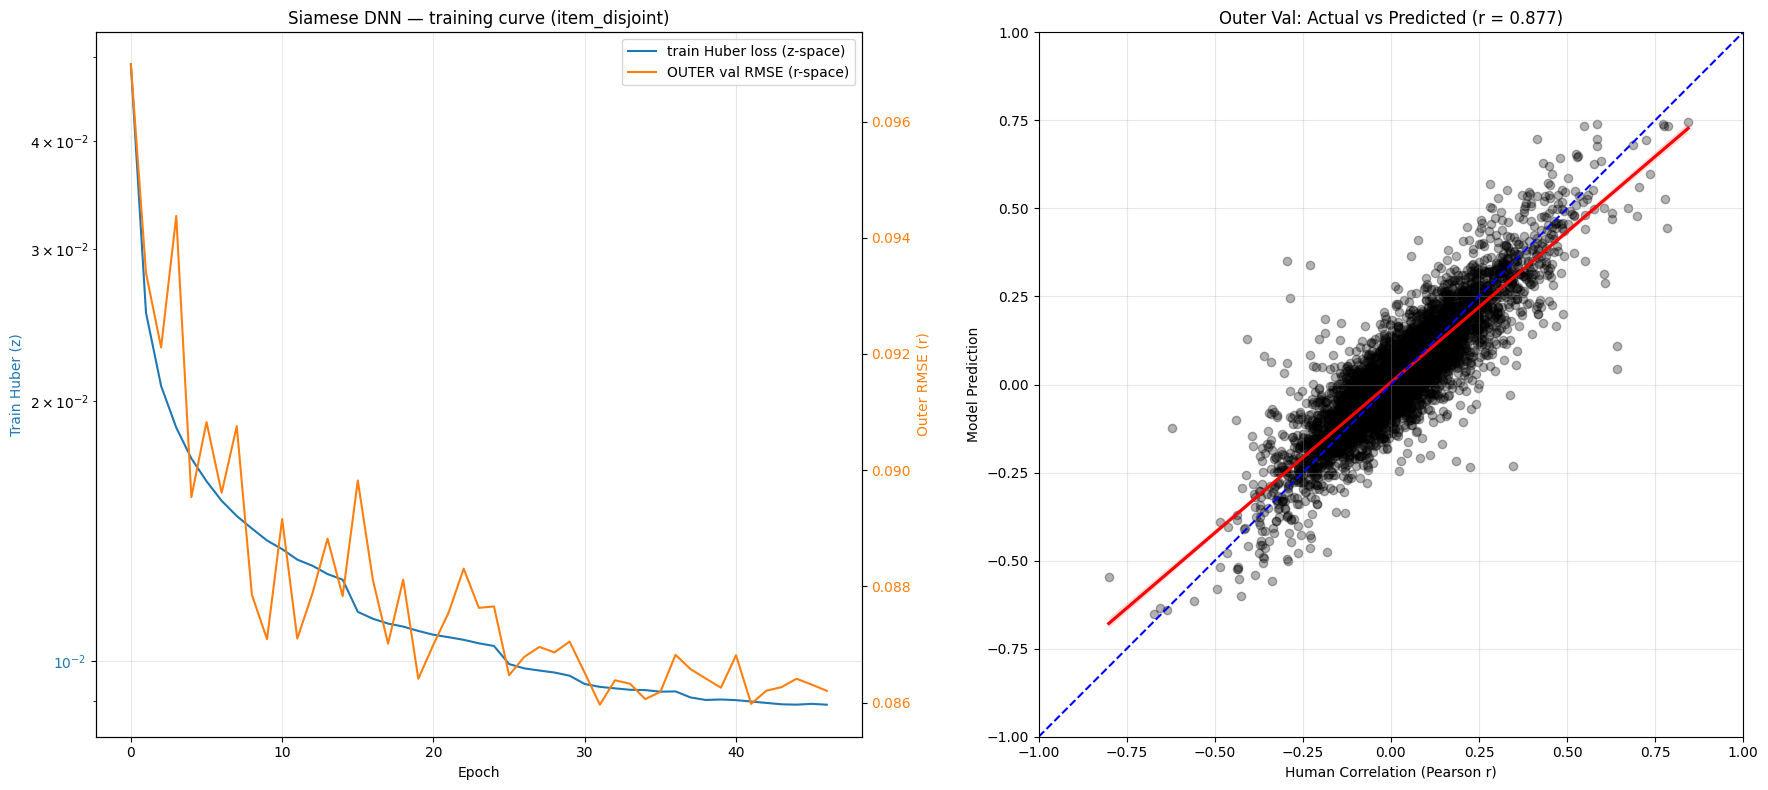

In [11]:
# --- 10. Diagnostic plots ---

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Training curve: Huber(z) on the left axis, r-space RMSE on the right
ax_l = axes[0]
ax_l.plot(history["train_loss"], label="train Huber loss (z-space)", color="tab:blue")
ax_l.set_xlabel("Epoch"); ax_l.set_ylabel("Train Huber (z)", color="tab:blue")
ax_l.tick_params(axis="y", labelcolor="tab:blue"); ax_l.set_yscale("log")
ax_r = ax_l.twinx()
ax_r.plot(history["outer_val_rmse"], label="OUTER val RMSE (r-space)", color="tab:orange")
ax_r.set_ylabel("Outer RMSE (r)", color="tab:orange")
ax_r.tick_params(axis="y", labelcolor="tab:orange")
lines_l, lab_l = ax_l.get_legend_handles_labels()
lines_r, lab_r = ax_r.get_legend_handles_labels()
ax_l.legend(lines_l + lines_r, lab_l + lab_r, loc="upper right")
ax_l.set_title("Siamese DNN — training curve (item_disjoint)")
ax_l.grid(True, alpha=0.3)

# Predicted vs true on outer val (identity line in blue, fit line in red)
sns.regplot(
    x=y_true, y=y_pred, ax=axes[1],
    scatter_kws={"alpha": 0.3, "color": "black"},
    line_kws={"color": "red"},
)
axes[1].plot([-1, 1], [-1, 1], color="blue", linestyle="--")
axes[1].set_xlim(-1, 1); axes[1].set_ylim(-1, 1)
axes[1].set_aspect("equal", adjustable="box")
axes[1].set_title(f"Outer Val: Actual vs Predicted (r = {corr:.3f})")
axes[1].set_xlabel("Human Correlation (Pearson r)")
axes[1].set_ylabel("Model Prediction")
axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()


## Holdout evaluation

Scores the holdout pair file (Bainbridge s2, item-disjoint from
training) through the trained network. We build a *combined* item->idx lookup
(training items + holdout-only items) so a single pass scores the whole set,
then recompute `global_sim` (raw cosine over the embeddings) so the feature
matches what the model saw at training time. The standalone notebook
`model_validation.ipynb` does the same thing plus the validation set.


Holdout pair rows on disk: 87,153
Combined embedding lookup: 3,127 train + 292 new holdout = 3,419 items
After item-lookup filter: 87,153 pairs (dropped 0)

=== SIAMESE DNN HOLDOUT EVALUATION ===
N pairs:    87,153
Pearson r:  0.8667
R-squared:  0.7049
RMSE:       0.0885
MAE:        0.0683


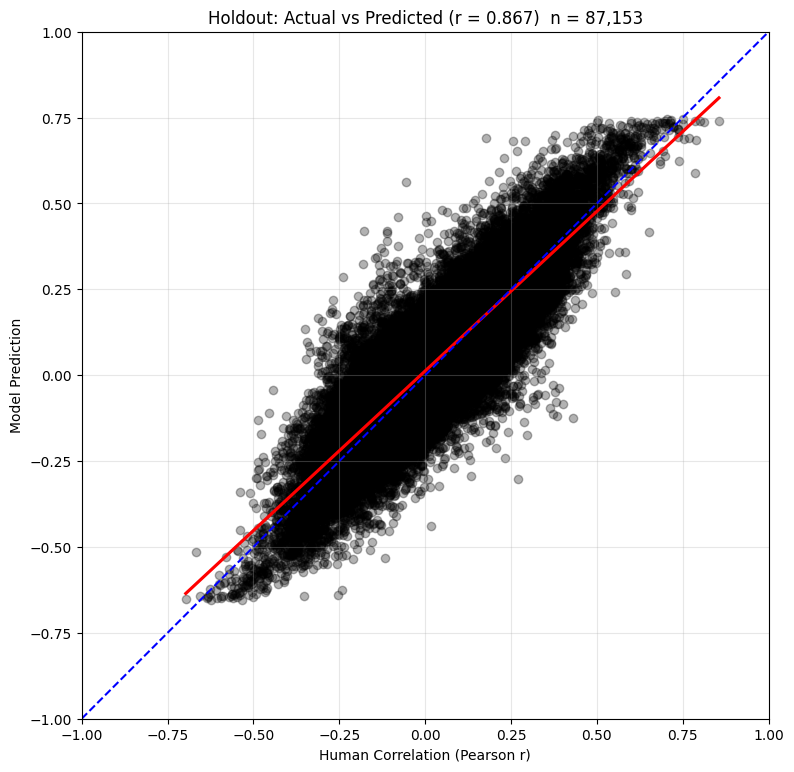

Slope: 0.9294 +/- 0.0018 (SE)


In [12]:
# --- 11. Holdout evaluation ---
# 1) Load the holdout pair file.
# 2) Build a COMBINED embedding lookup (train items + holdout-only items).
# 3) Drop pairs referencing items missing from the lookup.
# 4) Recompute global_sim as raw cosine over the embeddings (matches training).
# 5) Featurize through the train-fitted scaler.
# 6) Score all pairs in chunks and report metrics.

# ---- 1. Pair file ----
hold_df = pl.read_parquet(hold_pair_path).filter(
    (pl.col("r").is_not_null()) & (pl.col("r") != 1)
)
print(f"Holdout pair rows on disk: {hold_df.height:,}")

# ---- 2. Combined embedding lookup (train items first, then holdout-only items) ----
hold_emb_df   = pl.read_parquet(hold_emb_path)
hold_emb_cols = [c for c in hold_emb_df.columns if c.startswith("emb")]
assert len(hold_emb_cols) == EMB_DIM, "Holdout embedding dim doesn't match training dim"

combined_item_to_idx = dict(item_to_idx)
new_local_rows, new_names = [], []
for local_row, name in enumerate(hold_emb_df["item"].to_list()):
    if name not in combined_item_to_idx:
        combined_item_to_idx[name] = len(item_to_idx) + len(new_local_rows)
        new_local_rows.append(local_row)
        new_names.append(name)

if new_local_rows:
    hold_emb_np  = hold_emb_df.select(hold_emb_cols).to_numpy()[new_local_rows]
    HOLD_EMB_NEW = torch.tensor(hold_emb_np, dtype=torch.float32).to(device)
    COMBINED_EMB = torch.cat([ITEM_EMB, HOLD_EMB_NEW], dim=0)
else:
    COMBINED_EMB = ITEM_EMB
print(f"Combined embedding lookup: {len(item_to_idx):,} train + {len(new_names):,} new holdout = {COMBINED_EMB.shape[0]:,} items")

# ---- 3. Drop any pairs referencing items still unknown (should be 0) ----
known = pl.Series("item", list(combined_item_to_idx.keys())).implode()
pre_n = hold_df.height
hold_df = hold_df.filter(
    pl.col("Parameter1").is_in(known) & pl.col("Parameter2").is_in(known)
)
print(f"After item-lookup filter: {hold_df.height:,} pairs (dropped {pre_n - hold_df.height:,})")

# ---- 4. global_sim = raw cosine over all embedding dims (matches training) ----
hold_df = add_global_sim(hold_df, COMBINED_EMB, combined_item_to_idx)

# indices for scoring, taken from the (now filtered) pair table
idx1 = np.fromiter((combined_item_to_idx[p] for p in hold_df["Parameter1"].to_list()), np.int64)
idx2 = np.fromiter((combined_item_to_idx[p] for p in hold_df["Parameter2"].to_list()), np.int64)

# ---- 6. Featurize through the train-fitted scaler ----
aux = scaler.transform(hold_df.select(aux_numeric).to_numpy())
y_h     = hold_df.select("r").to_numpy().flatten().astype(np.float32)

idx1_t = torch.tensor(idx1, dtype=torch.long, device=device)
idx2_t = torch.tensor(idx2, dtype=torch.long, device=device)
aux_t  = torch.tensor(aux,  dtype=torch.float32, device=device)

# ---- 7. Score in chunks and report ----
model.eval()
chunks = []
with torch.no_grad():
    for s in range(0, idx1_t.shape[0], 8192):
        e1 = COMBINED_EMB[idx1_t[s:s+8192]]
        e2 = COMBINED_EMB[idx2_t[s:s+8192]]
        ax_ = aux_t[s:s+8192]
        chunks.append(torch.tanh(model(e1, e2, ax_)).cpu().numpy())
h_preds = np.concatenate(chunks)

corr_h, _ = pearsonr(y_h, h_preds)
rmse_h    = np.sqrt(mean_squared_error(y_h, h_preds))
r2_h      = r2_score(y_h, h_preds)
mae_h     = mean_absolute_error(y_h, h_preds)

print("\n=== SIAMESE DNN HOLDOUT EVALUATION ===")
print(f"N pairs:    {len(y_h):,}")
print(f"Pearson r:  {corr_h:.4f}")
print(f"R-squared:  {r2_h:.4f}")
print(f"RMSE:       {rmse_h:.4f}")
print(f"MAE:        {mae_h:.4f}")

# Predicted vs true with the identity line
fig, ax = plt.subplots(figsize=(8, 8))
sns.regplot(
    x=y_h, y=h_preds, ax=ax,
    scatter_kws={"alpha": 0.3, "color": "black"},
    line_kws={"color": "red"},
    ci=99,
)
ax.plot([-1, 1], [-1, 1], color="blue", linestyle="--")
ax.set_xlim(-1, 1); ax.set_ylim(-1, 1); ax.set_aspect("equal", adjustable="box")
ax.set_title(f"Holdout: Actual vs Predicted (r = {corr_h:.3f})  n = {len(y_h):,}")
ax.set_xlabel("Human Correlation (Pearson r)")
ax.set_ylabel("Model Prediction")
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# Quick check that the fit isn't biased (slope close to 1, intercept close to 0)
from scipy import stats
slope, intercept, r, pval, se = stats.linregress(y_h, h_preds)
print(f"Slope: {slope:.4f} +/- {se:.4f} (SE)")